1. Il reddito medio (MedInc) sembra il predittore più forte. Ma un reddito alto in una zona desertica vale quanto lo stesso reddito a San Francisco? Quale altra variabile potresti 'mescolare' con il reddito per capire meglio la capacità di acquisto in quella zona?

2. Se dividete il reddito in 10 gruppi (decili), il prezzo delle case sale sempre della stessa quantità tra un gruppo e l'altro? O c'è un punto in cui, anche se il reddito raddoppia, il prezzo della casa smette di salire drasticamente?

3. Ci aspetteremmo che le case più vecchie costino meno. Ma se create dei bin per l'età, i prezzi medi seguono davvero una linea discesa? O c'è un 'ritorno di fiamma' dove le case molto vecchie tornano a costare tanto quanto quelle nuove?

4. Arrotondate la latitudine e la longitudine all'intero più vicino. Ora calcolate il prezzo medio per ogni 'cella' della scacchiera. Quali celle sono dei deserti economici e quali sono miniere d'oro? Ci sono celle vicine con prezzi opposti?

5. C'è una relazione tra quanto è 'affollata' una casa e il suo valore? Provate a vedere il prezzo medio per i bin di AveOccup. Notate dei valori estremi (bin con 20+ persone)?

6. C'è un altro istogramma, oltre a quello del prezzo, che si interrompe bruscamente con un picco finale. Quale? Cosa succede a una casa che ha 53 o 60 anni in questo dataset? Viene registrata correttamente o finisce in un 'calderone' comune?

7. Sappiamo che San Francisco e Los Angeles sono i poli economici. Se calcolaste la distanza di ogni casa dal centro di queste due città, pensate che questa 'nuova coordinata' spiegherebbe il prezzo meglio della semplice latitudine?

8. Se una casa ha un AveOccup di 1.5 persone e un'altra di 6 persone, quale vi aspettereste che costi di più? Ora verificate nei dati: la vostra intuizione regge o i dati vi stanno dicendo che troppa gente in poco spazio 'affonda' il valore dell'immobile?

# Punto 1:

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
Correlazione con Latitude: -0.1441602768746593
Correlazione con Dist_Citta_Piu_Vicina: -0.43345611136904505


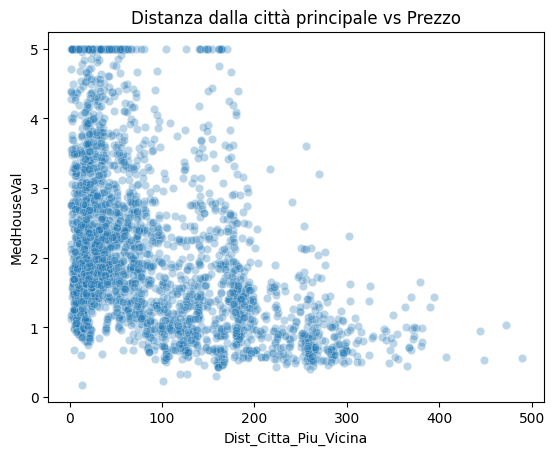

In [1]:
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing(as_frame=True)

# Access the features (X) and target (y)
df = housing.frame
print(df.head())

import numpy as np

# Funzione Haversine
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Raggio medio della Terra in km
    
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

# Coordinate città
sf_lat, sf_lon = 37.7749, -122.4194
la_lat, la_lon = 34.0522, -118.2437

# Distanze
df["Dist_SF"] = haversine(df["Latitude"], df["Longitude"], sf_lat, sf_lon)
df["Dist_LA"] = haversine(df["Latitude"], df["Longitude"], la_lat, la_lon)

# Distanza dal polo più vicino
df["Dist_Citta_Piu_Vicina"] = df[["Dist_SF", "Dist_LA"]].min(axis=1)

print("Correlazione con Latitude:",
      df["Latitude"].corr(df["MedHouseVal"]))

print("Correlazione con Dist_Citta_Piu_Vicina:",
      df["Dist_Citta_Piu_Vicina"].corr(df["MedHouseVal"]))

import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df.sample(3000, random_state=42),
    x="Dist_Citta_Piu_Vicina",
    y="MedHouseVal",
    alpha=0.3
)

plt.title("Distanza dalla città principale vs Prezzo")
plt.show()

# Punto 2:

   Decile_Reddito  MedHouseVal
0               0     1.101797
1               1     1.266338
2               2     1.477231
3               3     1.663145
4               4     1.862524
5               5     2.015082
6               6     2.207469
7               7     2.393294
8               8     2.799943
9               9     3.899877


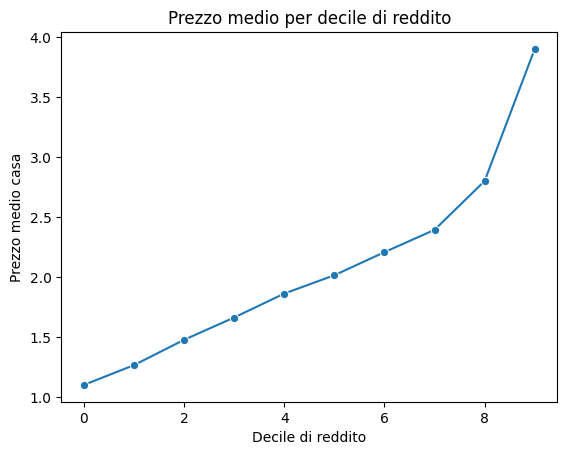

np.float64(5.00001)

In [2]:
import pandas as pd
import numpy as np

# Creiamo i decili (10 gruppi con stessa numerosità)
df["Decile_Reddito"] = pd.qcut(df["MedInc"], 10, labels=False)

prezzo_medio_decili = (
    df.groupby("Decile_Reddito")["MedHouseVal"]
    .mean()
    .reset_index()
)

print(prezzo_medio_decili)

import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(
    data=prezzo_medio_decili,
    x="Decile_Reddito",
    y="MedHouseVal",
    marker="o"
)

plt.title("Prezzo medio per decile di reddito")
plt.xlabel("Decile di reddito")
plt.ylabel("Prezzo medio casa")
plt.show()

df["MedHouseVal"].max()


In [ ]:
ultimo_decile = df[df["Decile_Reddito"] == 9]
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(ultimo_decile["MedHouseVal"])
plt.title("Distribuzione Prezzi - Ultimo Decile di Reddito")
plt.ylabel("MedHouseVal")
plt.show()

print("Prezzo massimo:", ultimo_decile["MedHouseVal"].max())
print("Percentuale case al cap (5.0):",
      (ultimo_decile["MedHouseVal"] == 5.0).mean() * 100)

